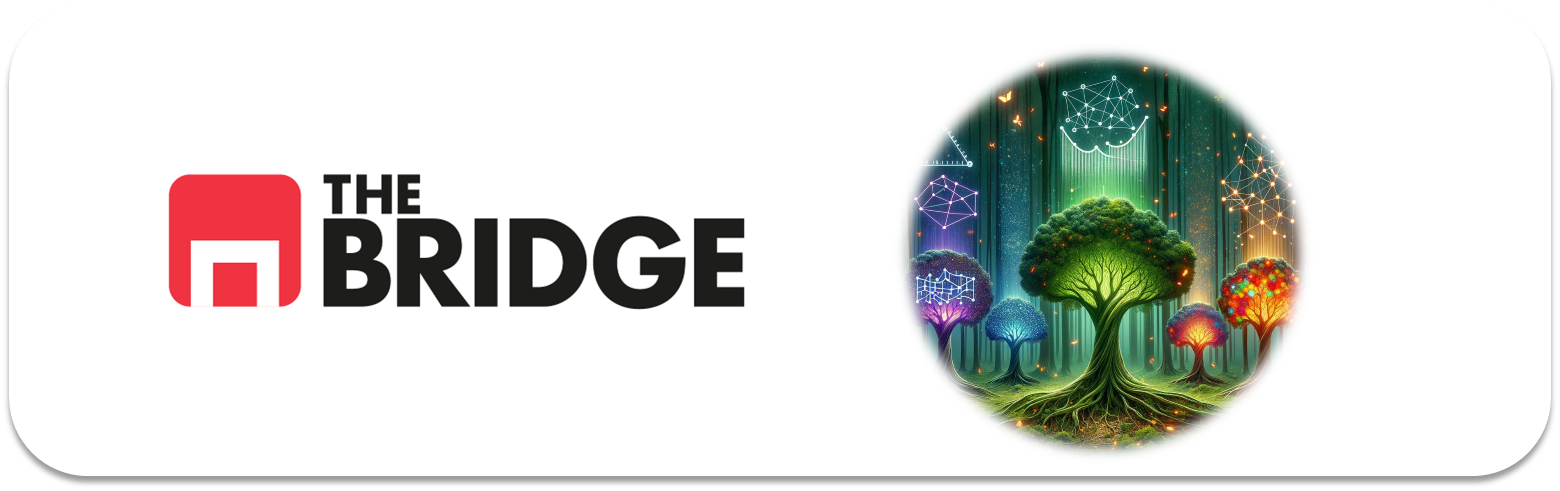

## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np
from scipy import stats

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, LabelEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import (
    LinearRegression, LogisticRegression,
    Ridge, Lasso, ElasticNet
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)

# Métricas de regresión
from sklearn.metrics import (
    mean_squared_error, root_mean_squared_error,
    mean_absolute_error, r2_score
)

# Métricas de clasificación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')
pd.options.mode.copy_on_write = True

### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos 21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las características del dataset incluyen varios predictores médicos y un objetivo que indica si la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista de nombres sugeridos para las columnas:


In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

In [6]:
df = pd.read_csv(url, names=names)
df.head()


,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menoss tres modelos a partir de tecnologías de bagging y boosting (al menos uno de cada), compáralos sin utilizar el test y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de test que deberás haber reservado con anterioridad.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
import sys
sys.path.append(r"c:\Users\Usuario\Documents\GitHub\DS-Online-Marta-Harana\Apuntes")
from definiciones import describe_df, tipifica_variables

In [9]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
preg,int64,0.0,17,2.21
plas,int64,0.0,136,17.71
pres,int64,0.0,47,6.12
skin,int64,0.0,51,6.64
test,int64,0.0,186,24.22
mass,float64,0.0,248,32.29
pedi,float64,0.0,517,67.32
age,int64,0.0,52,6.77
class,int64,0.0,2,0.26


In [10]:
TARGET = 'class'  # ← Cambia esto por el nombre de tu columna objetivo

n_unique = df[TARGET].nunique()
print(f"Valores únicos en la target: {n_unique}")

if n_unique <= 20:
    print("→ Posible CLASIFICACIÓN")
    print(df[TARGET].value_counts())
else:
    print("→ Posible REGRESIÓN")
    print(df[TARGET].describe())

Valores únicos en la target: 2
→ Posible CLASIFICACIÓN
class
0    500
1    268
Name: count, dtype: int64


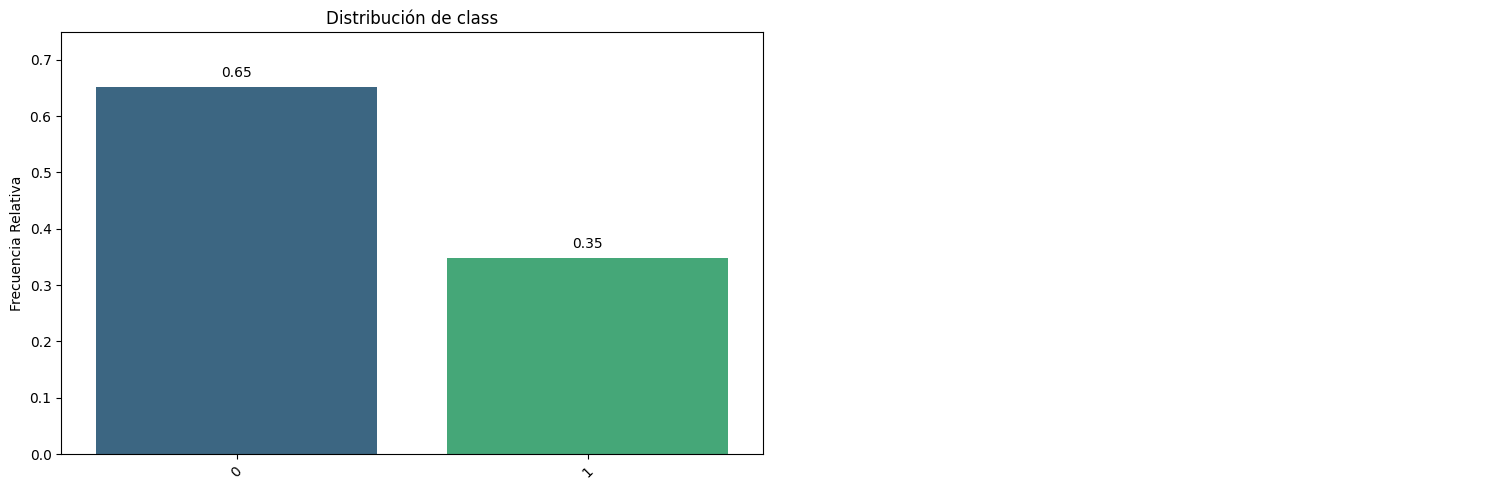

In [14]:
# Es un problema de clasificación desbalanceado
from bootcampviztools import pinta_distribucion_categoricas
pinta_distribucion_categoricas(df, [TARGET], mostrar_valores = True, relativa=True)

In [13]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20 % para test
    random_state=42,     # Fija la semilla → resultados reproducibles
    stratify=y           # Descomentar en clasificación con clases desbalanceadas
)

print(f"Train: {X_train.shape[0]} filas  ({X_train.shape[0]/len(df)*100:.0f} %)")
print(f"Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(df)*100:.0f} %)")

Train: 614 filas  (80 %)
Test:  154 filas  (20 %)


In [17]:
# Tipos de datos
print(X_train.dtypes)
print()

# Valores faltantes
missing = X_train.isna().sum()
missing_pct = (missing / len(X_train) * 100).round(1)
resumen = pd.DataFrame({'count': missing, '%': missing_pct})
print(resumen[resumen['count'] > 0].sort_values('%', ascending=False))
print()

# Duplicados
print(f"Duplicados: {X_train.duplicated().sum()}")

preg      int64
plas      int64
pres      int64
skin      int64
test      int64
mass    float64
pedi    float64
age       int64
dtype: object

Empty DataFrame
Columns: [count, %]
Index: []

Duplicados: 0


In [22]:
df.describe()

,preg,plas,pres,skin,test,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# los valores 0, son como si fueran nulos por lo tanto los cambiamos por NaN
# con la función describe vemos los mínimos (0) hacemos un replace por np.nan

tienen_nulos = ['plas', 'pres', 'skin', 'test', 'mass']

X_train[tienen_nulos] = X_train[tienen_nulos].replace(0, np.nan)

X_test[tienen_nulos] = X_test[tienen_nulos].replace(0, np.nan)

In [ ]:
from sklearn.impute import SimpleImputer

inp = SimpleImputer(strategy="median")

# se entrena y transforma en train
X_train[tienen_nulos] = inp.fit_transform(X_train[tienen_nulos])

# se tranforma en test
X_test[tienen_nulos] = inp.transform(X_test[tienen_nulos])

In [25]:
X_train.describe()

,preg,plas,pres,skin,test,mass,pedi,age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.819218,121.671010,72.140065,29.042345,137.705212,32.448208,0.477428,33.366450
std,3.314148,30.003794,12.275119,8.891855,78.764767,6.824122,0.330300,11.833438
min,0.000000,56.000000,24.000000,7.000000,15.000000,18.200000,0.084000,21.000000
25%,1.000000,99.000000,64.000000,25.000000,120.000000,27.625000,0.245000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.400000,0.382500,29.000000
75%,6.000000,140.000000,80.000000,32.000000,130.000000,36.500000,0.639250,41.000000
max,17.000000,199.000000,122.000000,99.000000,744.000000,67.100000,2.329000,81.000000


In [26]:
features_num = X_train.columns.tolist()
features_num

['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

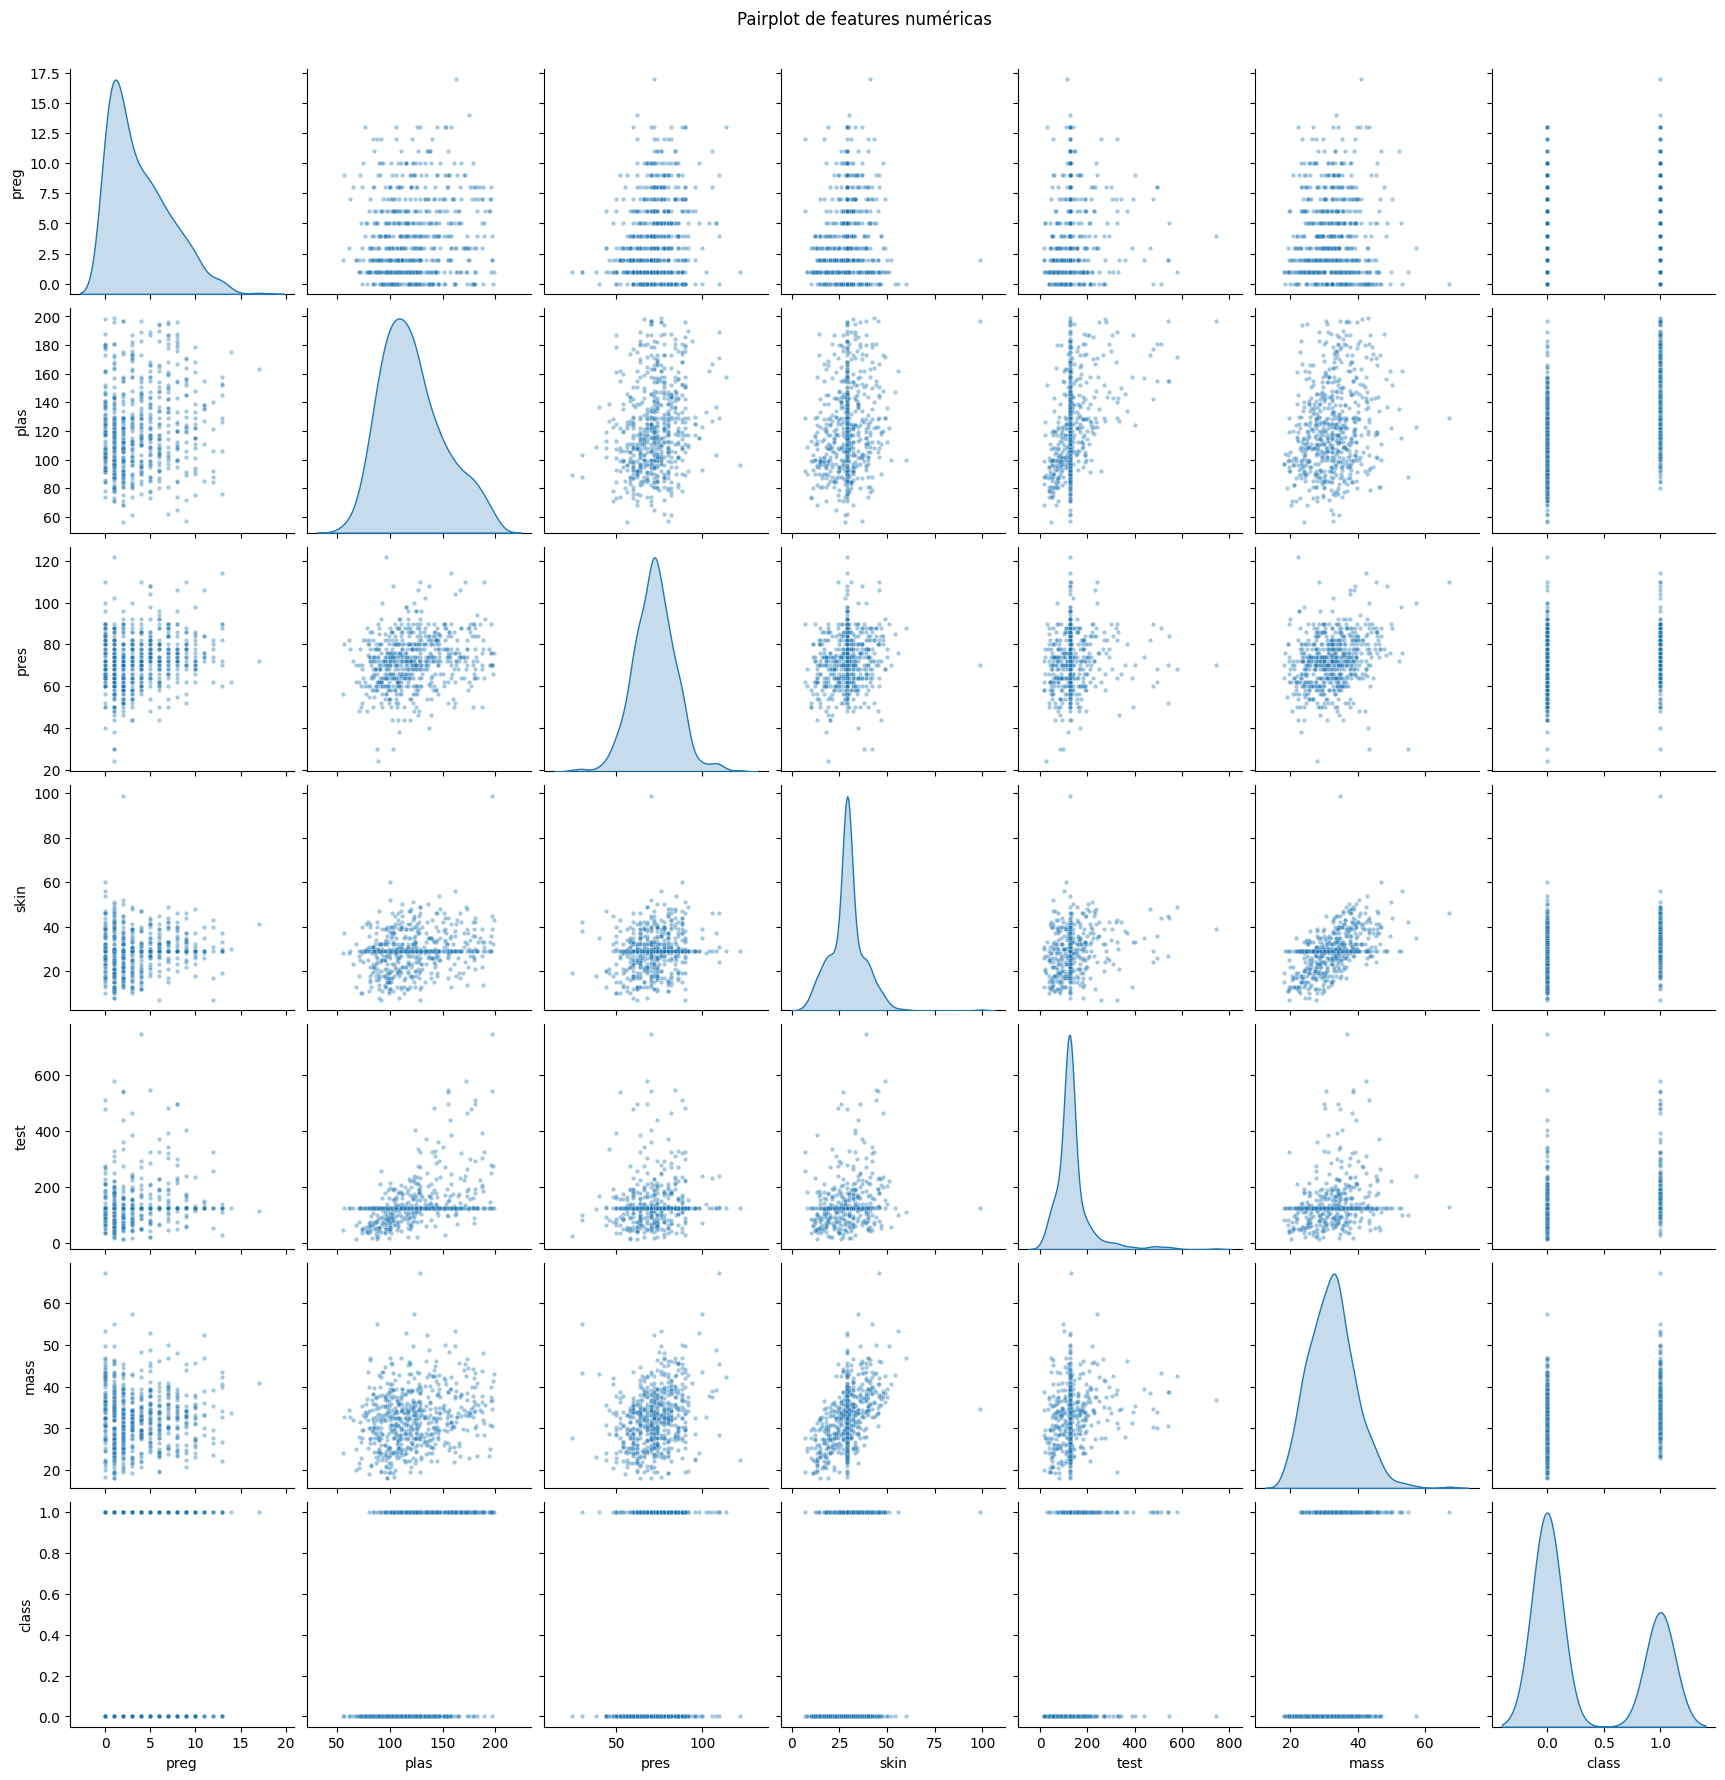

In [27]:
# Seleccionamos las features numéricas y añadimos la target
cols_plot = X_train.select_dtypes('number').columns.tolist()[:6]  # max 6 para legibilidad

sns.pairplot(
    X_train[cols_plot].join(y_train),
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 10}
)
plt.suptitle('Pairplot de features numéricas', y=1.02)
plt.show()

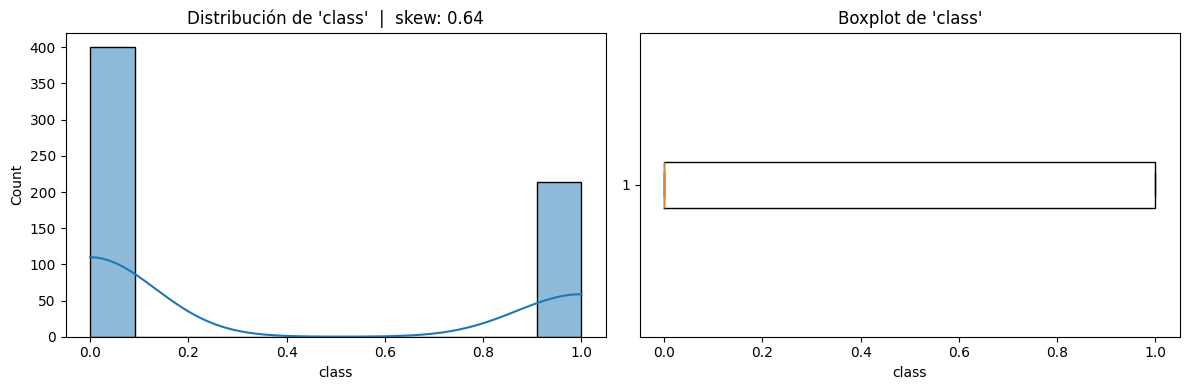

class
0    65.1
1    34.9
Name: proportion, dtype: float64


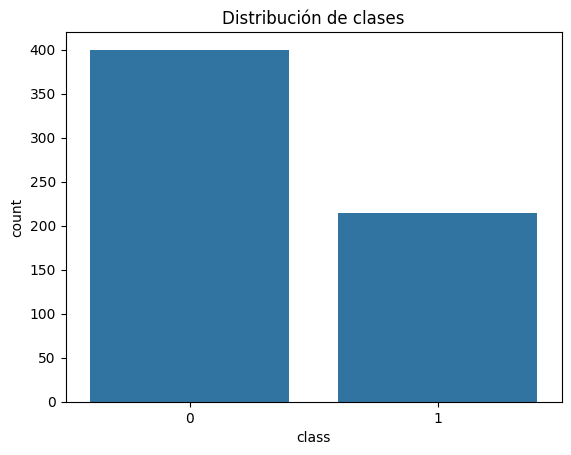

In [28]:
# Estudiamos la TARGET

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma con curva de densidad
sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title(f"Distribución de '{TARGET}'  |  skew: {y_train.skew():.2f}")

# Boxplot para ver outliers
axes[1].boxplot(y_train.dropna(), vert=False)
axes[1].set_title(f"Boxplot de '{TARGET}'")
axes[1].set_xlabel(TARGET)

plt.tight_layout()
plt.show()

# Para clasificación — descomenta esto:
sns.countplot(x=y_train)
plt.title('Distribución de clases')
print(y_train.value_counts(normalize=True).mul(100).round(1))

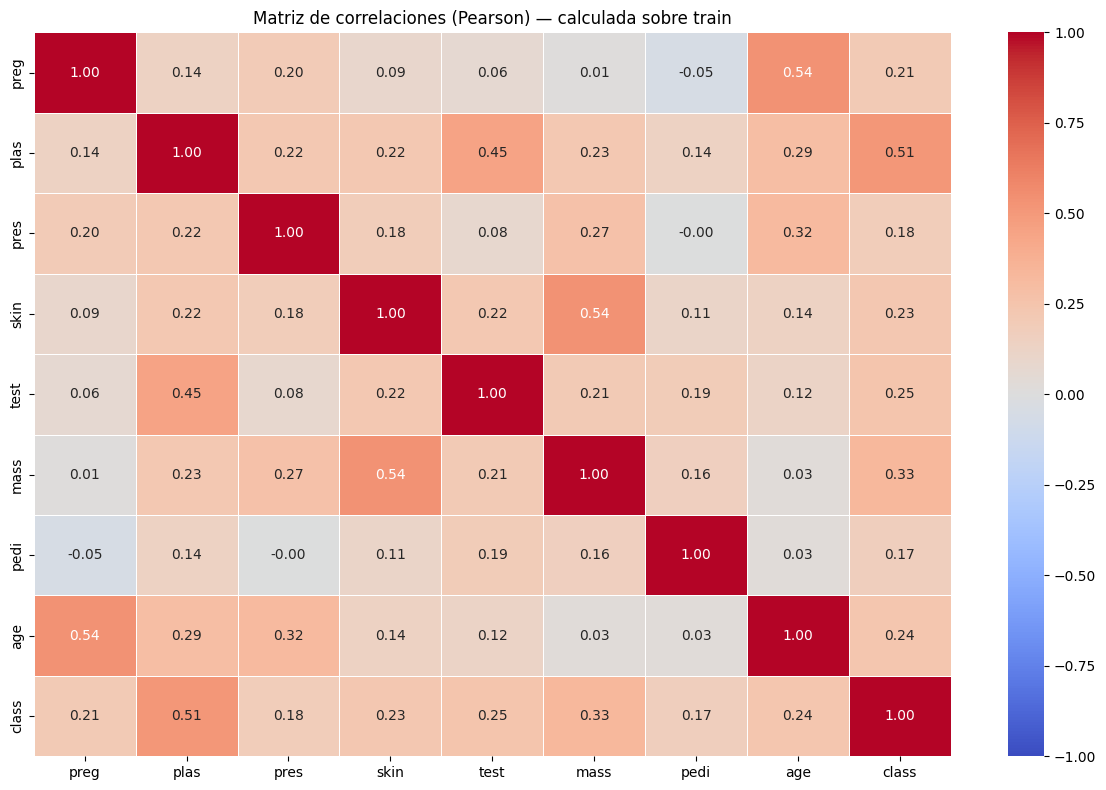


Correlación con la target:
plas    0.512291
mass    0.328774
test    0.245902
age     0.240676
skin    0.234260
preg    0.208173
pres    0.183373
pedi    0.165312


In [29]:
# Hacemos la matriz de correlaciones con nuestras variables numéricas

corr = X_train.join(y_train).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', vmin=-1, vmax=1,
            cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlaciones (Pearson) — calculada sobre train')
plt.tight_layout()
plt.show()

# Correlación de cada feature con la target, ordenada
print("\nCorrelación con la target:")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).to_string())

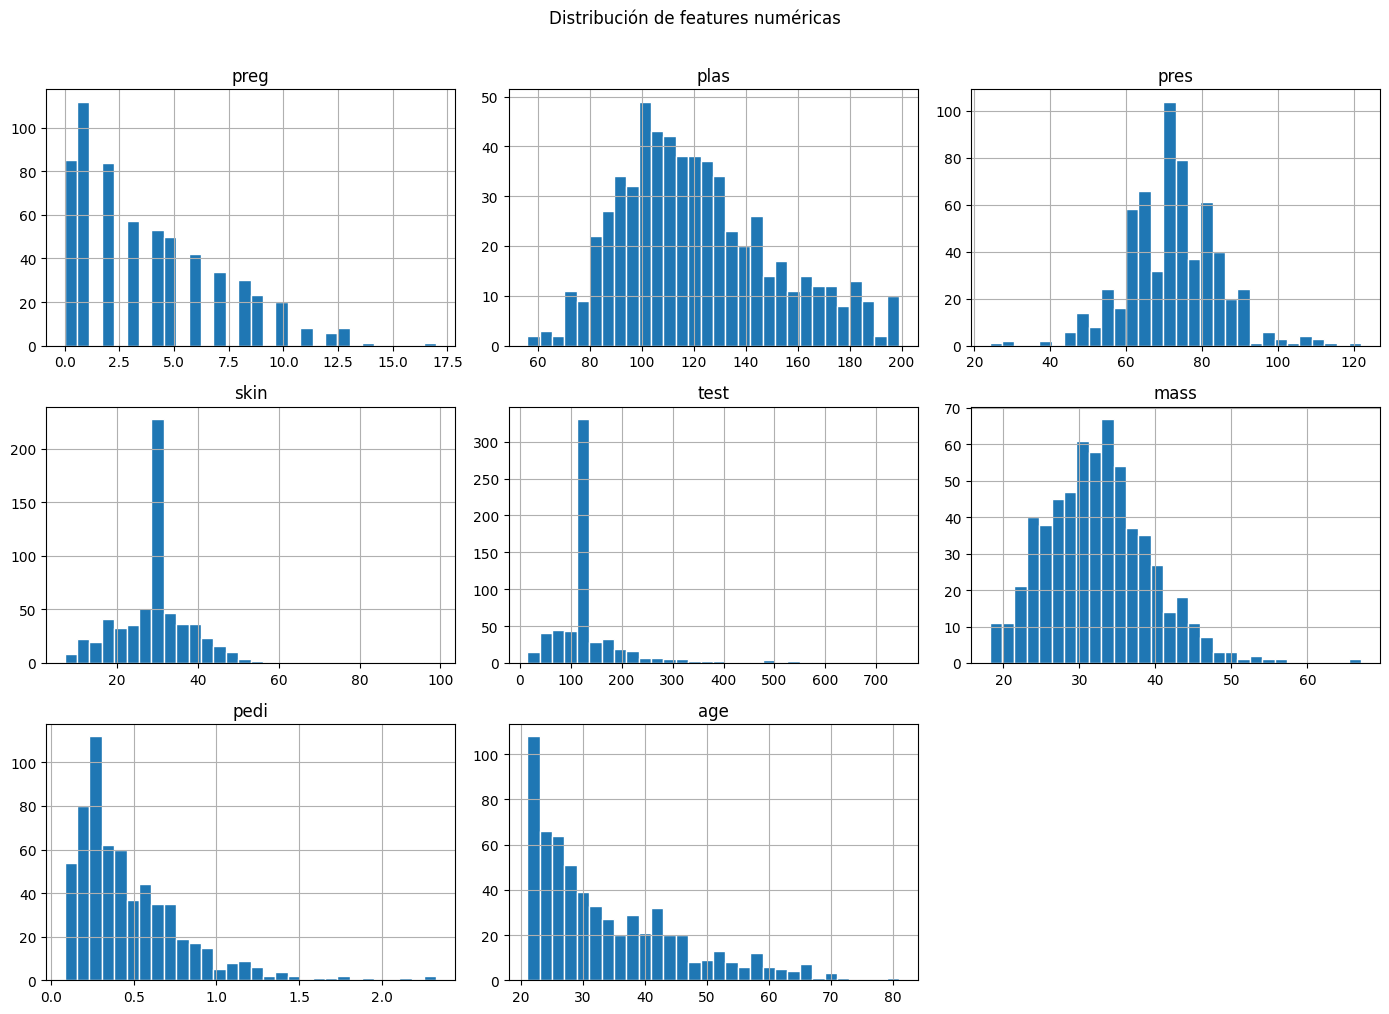

Skewness (asimetria) por feature:
test    3.076431
pedi    1.818910
age     1.128456
preg    0.886920
skin    0.886446
mass    0.573822
plas    0.556834
pres    0.115048


In [30]:
# Análisis univariante de nuestras features numéricas

X_train.select_dtypes('number').hist(figsize=(14, 10), bins=30, edgecolor='white')
plt.suptitle('Distribución de features numéricas', y=1.01)
plt.tight_layout()
plt.show()

# Skewness de cada feature numérica
skew = X_train.select_dtypes('number').skew().sort_values(key=abs, ascending=False)
print("Skewness (asimetria) por feature:")
print(skew.to_string())

In [21]:
# asimetría alta positiva → log1p
for col in ['test', 'pedi', 'age']:
    X_train[col] = np.log1p(X_train[col])
    X_test[col]  = np.log1p(X_test[col])

# asimetría alta negativa → cbrt
X_train['pres'] = np.cbrt(X_train['pres'])
X_test['pres']  = np.cbrt(X_test['pres'])

# asimetría media → sqrt
X_train['preg'] = np.sqrt(X_train['preg'])
X_test['preg']  = np.sqrt(X_test['preg'])


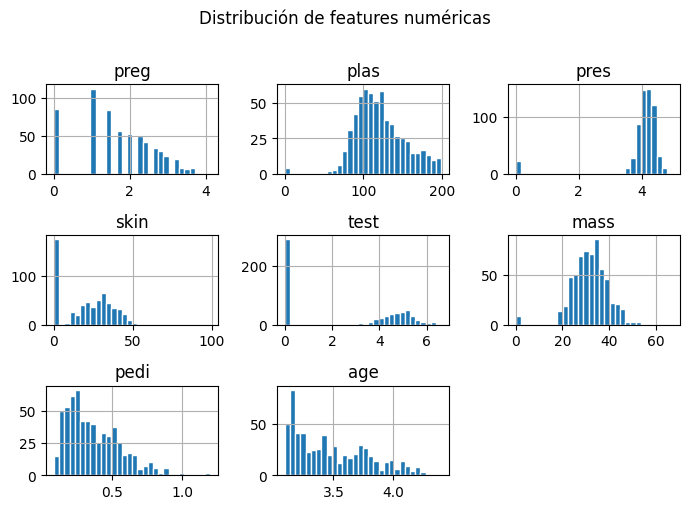

In [ ]:
# Visualización despues de la transformación

X_train.select_dtypes('number').hist(figsize=(7, 5), bins=30, edgecolor='white')
plt.suptitle('Distribución de features numéricas', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
X_train = train_set[features_num].copy()
# X_train_scaled
y_train = train_set[target]

X_test = test_set[features_num].copy()
# X_test_scaled
y_test = test_set[target]


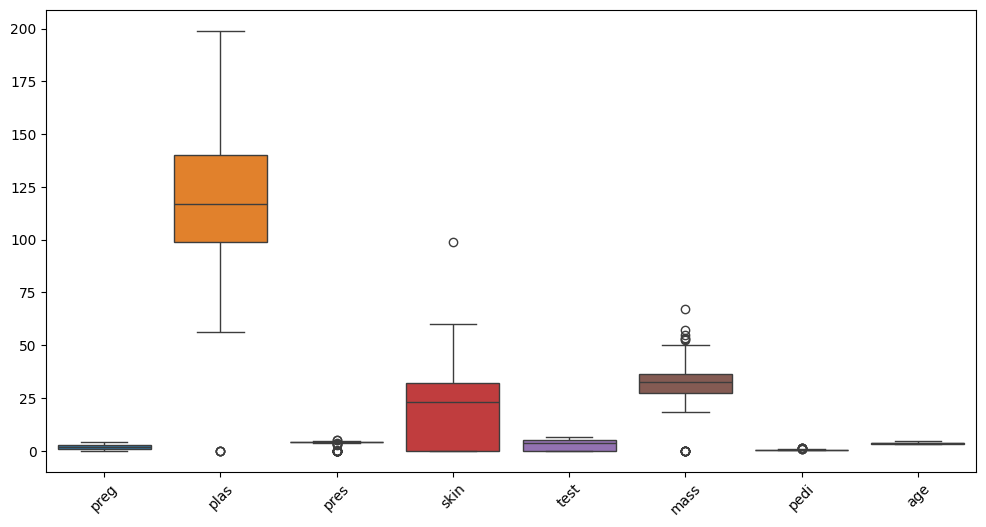

In [24]:
# Boxplot para visualizar si hay outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=X_train)
plt.xticks(rotation=45)
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

base_clf = RandomForestClassifier(max_depth=5, # para evitar overfiting
                                   random_state=42)

# hacemos un cv con esta base del Random forest
# scoring que nos interesa balanced_accuracy

In [36]:
scores = cross_val_score(base_clf, X_train, y_train, cv=5, scoring="balanced_accuracy")
print(f"Balanced Accuracy medio (CV=5): {scores.mean():.4f} ± {scores.std():.4f}")


Balanced Accuracy medio (CV=5): 0.7175 ± 0.0364


In [39]:
from sklearn.metrics import classification_report

base_clf.fit(X_train, y_train)
print("--- RandomForest baseline (train) ---")
print(classification_report(y_train, base_clf.predict(X_train)))

--- RandomForest baseline (train) ---
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       400
           1       0.86      0.68      0.76       214

    accuracy                           0.85       614
   macro avg       0.85      0.81      0.82       614
weighted avg       0.85      0.85      0.84       614



In [40]:
base_clf.feature_names_in_

array(['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age'],
      dtype=object)

In [41]:
base_clf.feature_importances_

array([0.06072573, 0.38296592, 0.04233269, 0.05339918, 0.10132026,
       0.16275494, 0.08469756, 0.11180371])

In [42]:
importancias_rf = pd.DataFrame({
    "feature": base_clf.feature_names_in_,
    "importance": base_clf.feature_importances_
}).sort_values("importance", ascending=False)

importancias_rf

,feature,importance
1,plas,0.382966
5,mass,0.162755
7,age,0.111804
4,test,0.101320
6,pedi,0.084698
0,preg,0.060726
3,skin,0.053399
2,pres,0.042333


# COMPARACIÓN DE MODELOS

In [43]:
xgb_clf = XGBClassifier(max_depth=5, random_state=42)
lgb_clf = LGBMClassifier(max_depth=5, random_state=42, verbose=-1, n_jobs=-1)

for nombre, modelo in zip(
    ["Random Forest", "XGBoost", "LightGBM"],
    [base_clf, xgb_clf, lgb_clf]
):
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring="balanced_accuracy")
    print(f"{nombre:15s} | Balanced Accuracy CV-5: {scores.mean():.4f} ± {scores.std():.4f}")


Random Forest   | Balanced Accuracy CV-5: 0.7175 ± 0.0364
XGBoost         | Balanced Accuracy CV-5: 0.6957 ± 0.0487
LightGBM        | Balanced Accuracy CV-5: 0.6877 ± 0.0244


### EL MEJOR ES RANDOM FOREST
Pero vamos a optimizar los 3 modelos

In [47]:
ratio_clases = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight = {ratio_clases:.4f} (negativos/positivos en train)")


scale_pos_weight = 1.8692 (negativos/positivos en train)


In [ ]:
# XGBOOST

param_grid_xgb = {
    "n_estimators": [100, 200],
    "eta": [0.01, 0.1],
    "max_depth": [3, 5],
    "min_child_weight": [1, 3],
    "scale_pos_weight": [ratio_clases],
    "colsample_bytree": [0.8, 1.0]
}

xgb_clf = XGBClassifier(random_state=42)

xgb_grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'eta': [0.01, 0.1], 'max_depth': [3, 5], 'min_child_weight': [1, 3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [49]:
xgb_grid.best_params_

{'colsample_bytree': 0.8,
 'eta': 0.01,
 'max_depth': 3,
 'min_child_weight': 3,
 'n_estimators': 200,
 'scale_pos_weight': np.float64(1.8691588785046729)}

In [50]:
xgb_grid.best_score_

np.float64(0.7483416389811739)

In [57]:
# Predicción frente al test
print("---XGBOOST OPTIMIZADO---")
print(classification_report(y_test, xgb_grid.best_estimator_.predict(X_test)))


---XGBOOST OPTIMIZADO---
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       100
           1       0.62      0.81      0.70        54

    accuracy                           0.76       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.79      0.76      0.76       154



In [52]:
# RANDOM FOREST

param_grid_rf = {
    "n_estimators": [100, 200, 400],
    "max_depth": [1, 5, 10, None],
    "min_samples_leaf": [1, 10, 20, 100],
    "class_weight": ["balanced", None],
    "max_features": ["sqrt", "log2", None]
}

rf_clf = RandomForestClassifier(random_state=42)

rf_grid = GridSearchCV(
    rf_clf,
    param_grid=param_grid_rf,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'max_depth': [1, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation 

In [53]:
rf_grid.best_params_

{'class_weight': 'balanced',
 'max_depth': 5,
 'max_features': None,
 'min_samples_leaf': 20,
 'n_estimators': 400}

In [54]:
rf_grid.best_score_

np.float64(0.7735714285714286)

In [56]:
# Predicción frente al test
print("---RANDOMFOREST OPTIMIZADO---")
print(classification_report(y_test, rf_grid.best_estimator_.predict(X_test)))

---RANDOMFOREST OPTIMIZADO---
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
           1       0.62      0.74      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154



In [59]:
# LIGHTGBM
from sklearn.model_selection import RandomizedSearchCV

param_dist_lgb = {
    "n_estimators": [100, 200, 400],
    "learning_rate": [0.01, 0.05, 0.1, 0.3],
    "max_depth": [3, 6, 10, -1],
    "num_leaves": [15, 31, 63, 127],
    "min_data_in_leaf": [1, 10, 20, 100],
    "class_weight": ["balanced", None],
    "max_bin": [40, 80, 200]
}

lgb_clf = LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1)

lgb_grid = RandomizedSearchCV(
    lgb_clf,
    param_distributions=param_dist_lgb,
    n_iter=60,
    cv=5,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=-1
)

lgb_grid.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', None], 'learning_rate': [0.01, 0.05, ...], 'max_bin': [40, 80, ...], 'max_depth': [3, 6, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be 

In [61]:
lgb_grid.best_params_

{'num_leaves': 31,
 'n_estimators': 400,
 'min_data_in_leaf': 100,
 'max_depth': 3,
 'max_bin': 200,
 'learning_rate': 0.01,
 'class_weight': 'balanced'}

In [62]:
lgb_grid.best_score_

np.float64(0.7607225913621263)

In [63]:
# Predicción frente al test
print("--- LGBOOST OPTIMIZADO---")
print(classification_report(y_test, lgb_grid.best_estimator_.predict(X_test)))

--- LGBOOST OPTIMIZADO---
              precision    recall  f1-score   support

           0       0.86      0.72      0.78       100
           1       0.60      0.78      0.68        54

    accuracy                           0.74       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.74      0.75       154



### --- DESDE AQUÍ ES MI PRÁCTICA ---

In [29]:
# Creo este diccionario para que se guarden las métricas
metricas_optimizadas = {}

In [32]:
# BAGGING

# RANDOM FOREST, MÉTRICA 

rf_clf = RandomForestClassifier(random_state=42, class_weight="balanced")

param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [2, 4, 10, None],
    "min_samples_leaf": [5, 10, 20, 40],
    "max_features": ["sqrt", "log2", None]
}

rf_grid = RandomizedSearchCV(
    estimator=rf_clf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    random_state=42
)

rf_grid.fit(X_train, y_train)

print("RF best_score (F1):", rf_grid.best_score_)
metricas_optimizadas["RandomForest"] = rf_grid.best_score_


RF best_score (F1): 0.6683154039012452


In [33]:
# BOOSTING
from xgboost import XGBClassifier


xgb_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
)

param_grid = {
    "max_depth": [2, 3, 4, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "n_estimators": [100, 200, 400, 600],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 1, 5]
}

xgb_grid = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid,
    n_iter=25,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42
)

xgb_grid.fit(X_train, y_train)

print("XGB best_score (F1):", xgb_grid.best_score_)
metricas_optimizadas["XGBoost"] = xgb_grid.best_score_


XGB best_score (F1): 0.6810071154898741


In [30]:
from lightgbm import LGBMClassifier

lgb_clf = LGBMClassifier(
    objective="binary",
    random_state=42,
    class_weight="balanced",
    verbose=-100
)

param_grid = {
    "n_estimators": [100, 200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, -1],
    "num_leaves": [15, 31, 63],
    "subsample": [0.6, 0.8, 1.0],          # antes bagging_fraction
    "colsample_bytree": [0.6, 0.8, 1.0],   # antes feature_fraction
    "min_child_samples": [5, 10, 20],
    "max_bin": [125, 255]
}

lgb_grid = RandomizedSearchCV(
    estimator=lgb_clf,
    param_distributions=param_grid,
    n_iter=25,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42
)

lgb_grid.fit(X_train, y_train)

print("LightGBM best_score (F1):", lgb_grid.best_score_)
metricas_optimizadas["LightGBM"] = lgb_grid.best_score_


LightGBM best_score (F1): 0.675959595959596


In [34]:
metricas_optimizadas

{'LightGBM': np.float64(0.675959595959596),
 'RandomForest': np.float64(0.6683154039012452),
 'XGBoost': np.float64(0.6810071154898741)}

In [35]:
# MÉTODO SELECCIONADO XGBOOST
best_xgb = xgb_grid.best_estimator_
best_xgb


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [36]:
#ENTRENAMOS EL MODELO CON ESTOS HIPERPARÁMETROS
best_xgb.fit(X_train, y_train)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [37]:
# PREDECIMOS CONTRA EL TEST
y_pred = best_xgb.predict(X_test)


In [41]:
# Evaluación del test

print("F1 en test:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))


F1 en test: 0.7096774193548387

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.74      0.80       100
           1       0.63      0.81      0.71        54

    accuracy                           0.77       154
   macro avg       0.75      0.78      0.76       154
weighted avg       0.79      0.77      0.77       154


Matriz de confusión:
[[74 26]
 [10 44]]
